# SX Phoenicis Period–Luminosity Distances

A validate-first notebook for measuring distances to SX Phe pulsators from their
period–luminosity relation, checked against Gaia.

**Structure**
1. Imports
2. All reusable functions (single library cell)
3. Reference sample: declare stars → build/load a persisted table (compute once)
4. PL relation plot (reads the table)
5. Your-data pipeline (run your own observation)
6. Comparison (your result vs. the table)

Every reference star requires an AAVSO CSV so its apparent magnitude is a real
intensity mean (no illustrative approximations). Absolute magnitude is cached in
the table.

## 1 · Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from astropy.timeseries import LombScargle
from astropy.time import Time
from astropy.coordinates import SkyCoord
import astropy.units as u
from astroquery.gaia import Gaia
from astroquery.simbad import Simbad

import time

print("imports ok")

imports ok


## 2 · Function library

All reusable functions live here. None of them hard-code a particular star —
each takes the star's parameters as arguments, so the same code serves the
reference sample and your own data.

In [2]:
# ---- PL relation coefficients (Cohen & Sarajedini 2012) --------------------
A_CS, A_ERR = -1.640, 0.110      # intercept (zero-point)
B_CS, B_ERR = -3.389, 0.090      # slope
SIGMA_INTRINSIC = 0.20           # intrinsic scatter of the relation (mag)


# ---- 1. period -> absolute magnitude --------------------------------------
def period_to_absmag(P_f, P_err=0.0, a=A_CS, a_err=A_ERR, b=B_CS, b_err=B_ERR,
                     include_intrinsic=True):
    """M_V from fundamental-mode period (days), with propagated 1-sigma error.
    Calibration-only error unless include_intrinsic adds the ~0.20 mag scatter."""
    logP = np.log10(P_f)
    M_V  = a + b * logP
    sig_logP = P_err / (P_f * np.log(10))
    var_cal  = a_err**2 + (logP * b_err)**2 + (b * sig_logP)**2
    var_M    = var_cal + (SIGMA_INTRINSIC**2 if include_intrinsic else 0.0)
    return M_V, np.sqrt(var_M)


# ---- 2. distance modulus --------------------------------------------------
def distance_from_modulus(m, M, A_V=0.0, m_err=0.0, M_err=0.0, A_err=0.0):
    """Distance (pc) from apparent & absolute magnitude + extinction, with error."""
    mu0 = m - M - A_V
    d   = 10**((mu0 + 5) / 5)
    sig_mu = np.sqrt(m_err**2 + M_err**2 + A_err**2)
    d_err  = d * (np.log(10) / 5) * sig_mu
    return d, d_err


def absmag_from_distance(m, d_pc, A_V=0.0):
    """True M_V from apparent mag + an INDEPENDENT distance (e.g. Gaia).
    M = m - 5*log10(d) + 5 - A_V.  Used to place stars on the PL plot."""
    return m - 5*np.log10(d_pc) + 5 - A_V


# ---- 3. period recovery (Lomb-Scargle) ------------------------------------
def find_period(times, mags, p_min=0.02, p_max=0.15, samples_per_peak=10):
    """Recover the dominant period via Lomb-Scargle. Timing only; band-agnostic.
    NOTE: needs several elapsed cycles AND dense multi-night sampling to avoid
    aliases. One short night (<~2 cycles) is unreliable."""
    times = np.asarray(times, float); mags = np.asarray(mags, float)
    f_min, f_max = 1.0/p_max, 1.0/p_min
    freq, power = LombScargle(times, mags).autopower(
        minimum_frequency=f_min, maximum_frequency=f_max,
        samples_per_peak=samples_per_peak)
    best = freq[np.argmax(power)]
    return 1.0/best, {"period_grid": 1.0/freq, "power": power,
                      "best_period": 1.0/best, "best_power": power.max()}


def plot_periodogram(diag, known_period=None, title="Lomb-Scargle periodogram"):
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(diag["period_grid"], diag["power"], lw=0.8, color="steelblue")
    ax.axvline(diag["best_period"], color="crimson",
               label=f"recovered = {diag['best_period']:.6f} d")
    if known_period:
        ax.axvline(known_period, color="green", ls="--",
                   label=f"reference = {known_period:.6f} d")
    ax.set(xlabel="period (days)", ylabel="LS power", title=title)
    ax.legend(); plt.tight_layout(); plt.show()


# ---- 4. fold + intensity mean ---------------------------------------------
def fold_and_mean(times, mags, period, t0=None, n_bins=20):
    """Intensity-mean magnitude over one folded cycle (flux-averaged, phase-
    uniform). Returns (mean_mag, diag). Empty phase bins are skipped and
    reported, never invented."""
    times = np.asarray(times, float); mags = np.asarray(mags, float)
    if t0 is None: t0 = times.min()
    phase = ((times - t0) / period) % 1.0
    flux  = 10**(-0.4 * mags)
    edges = np.linspace(0, 1, n_bins + 1)
    idx   = np.clip(np.digitize(phase, edges) - 1, 0, n_bins - 1)
    bin_flux = np.full(n_bins, np.nan); bin_n = np.zeros(n_bins, int)
    for b in range(n_bins):
        sel = idx == b; bin_n[b] = sel.sum()
        if bin_n[b]: bin_flux[b] = flux[sel].mean()
    occ = bin_n > 0
    mean_mag = -2.5*np.log10(np.nanmean(bin_flux[occ]))
    diag = {"phase": phase, "mags": mags,
            "bin_centers": 0.5*(edges[:-1]+edges[1:]),
            "bin_mag": -2.5*np.log10(bin_flux), "occupied": occ,
            "n_empty": int((~occ).sum()), "coverage": occ.mean(),
            "mean_mag": mean_mag, "naive": mags.mean(), "period": period}
    return mean_mag, diag


def plot_folded(diag, title="folded light curve", band="mag"):
    bc, bm = diag["bin_centers"], diag["bin_mag"]
    fig, ax = plt.subplots(figsize=(8, 5))
    for s in (0, 1):
        ax.scatter(diag["phase"]+s, diag["mags"], s=8, alpha=0.4, color="gray",
                   label="data" if s == 0 else None)
        ax.plot(bc+s, bm, "o-", color="crimson",
                label="phase-binned mean" if s == 0 else None)
    ax.axhline(diag["mean_mag"], ls="--", color="navy",
               label=f"intensity mean = {diag['mean_mag']:.3f}")
    w = 1.0/len(bc)
    for c, o in zip(bc, diag["occupied"]):
        if not o:
            for s in (0, 1):
                ax.axvspan(c+s-w/2, c+s+w/2, color="orange", alpha=0.2)
    ax.invert_yaxis()
    ax.set(xlabel="phase", ylabel=f"{band} (mag)", title=title)
    ax.legend(loc="best"); plt.tight_layout(); plt.show()


# ---- 5. AAVSO loader ------------------------------------------------------
def load_aavso(path, band="V", transformed_only=False,
               valid_flags=("V", "Z"), densest_night=False):
    """AAVSO WebObs CSV -> (times, mags, meta). band selects the filter.
    densest_night=False folds ALL nights (best for a rich mean)."""
    df = pd.read_csv(path, low_memory=False)
    df.columns = [c.strip() for c in df.columns]
    sel = df["Band"] == band
    d = df[sel].copy()
    d["mag"] = pd.to_numeric(d["Magnitude"], errors="coerce")
    tcol = "HJD" if ("HJD" in d.columns and d["HJD"].notna().any()) else "JD"
    d["t"] = pd.to_numeric(d[tcol], errors="coerce")
    if transformed_only and "Transformed" in d.columns:
        d = d[d["Transformed"] == "Yes"]
    if valid_flags and "Validation Flag" in d.columns:
        d = d[d["Validation Flag"].isin(valid_flags)]
    d = d.dropna(subset=["mag", "t"]).sort_values("t")
    meta = {"n_total": int(sel.sum()), "n_clean": len(d), "tcol": tcol}
    if densest_night:
        d["night"] = np.floor(d["t"] - 0.5).astype(int)
        best = d.groupby("night").size().sort_values(ascending=False).index[0]
        d = d[d["night"] == best]
        meta.update(night=int(best), n_night=len(d),
                    span_hours=(d["t"].max()-d["t"].min())*24)
    return d["t"].values, d["mag"].values, meta


# ---- 6. Gaia distance by name (SIMBAD -> Gaia DR3 -> Bailer-Jones) ---------
def gaia_distance(name, radius_arcsec=3.0, retries=3, pause=5):
    """Resolve a name via SIMBAD, return Bailer-Jones geometric distance dict
    {d, lo, hi, parallax, source_id, G, bp_rp}. Retries on transient failures."""
    res = Simbad.query_object(name)
    if res is None or len(res) == 0:
        raise RuntimeError(f"SIMBAD could not resolve {name!r}")
    ra_col  = "ra"  if "ra"  in res.colnames else "RA"
    dec_col = "dec" if "dec" in res.colnames else "DEC"
    try:
        c = SkyCoord(float(res[ra_col][0])*u.deg, float(res[dec_col][0])*u.deg, frame="icrs")
    except (ValueError, TypeError):
        c = SkyCoord(str(res[ra_col][0]), str(res[dec_col][0]),
                     unit=(u.hourangle, u.deg), frame="icrs")
    r = radius_arcsec/3600.0
    adql = f"""
    SELECT g.source_id, g.parallax, g.parallax_error, g.phot_g_mean_mag, g.bp_rp,
           bj.r_med_geo, bj.r_lo_geo, bj.r_hi_geo
    FROM gaiadr3.gaia_source AS g
    JOIN external.gaiaedr3_distance AS bj ON g.source_id = bj.source_id
    WHERE 1=CONTAINS(POINT('ICRS', g.ra, g.dec),
                     CIRCLE('ICRS', {c.ra.deg}, {c.dec.deg}, {r}))
    ORDER BY g.phot_g_mean_mag ASC
    """
    for attempt in range(retries):
        try:
            t = Gaia.launch_job(adql).get_results()
            break
        except Exception as e:
            print(f"    {name}: Gaia attempt {attempt+1} failed "
                  f"({type(e).__name__}); retrying...")
            time.sleep(pause)
    else:
        raise RuntimeError(f"Gaia unreachable for {name}")
    if len(t) == 0:
        raise RuntimeError(f"no Gaia source found for {name}")
    row = t[0]
    return {"d": float(row["r_med_geo"]),
            "lo": float(row["r_lo_geo"]), "hi": float(row["r_hi_geo"]),
            "parallax": float(row["parallax"]),
            "parallax_err": float(row["parallax_error"]),
            "source_id": int(row["source_id"]),
            "G": float(row["phot_g_mean_mag"]), "bp_rp": float(row["bp_rp"])}


print("function library loaded")

function library loaded


## 3 · Reference sample → persisted table

Declare the SX Phe stars below. Each needs: a **name** (SIMBAD-resolvable), a
**fundamental period** (days, from literature), and an **AAVSO CSV** whose V-band
data gives a real intensity mean.

The cell also assigns each star a **quality grade (A/B/C)** combining objective
metrics — phase coverage, number of points, Gaia parallax fractional error, and
whether the entered period matches what `find_period` recovers from the data —
with two manual flags you set per star: pulsation **mode** (single/double/
uncertain) and **population** (SXPhe / Pop-I dSct). A weakness in any dimension
caps the grade, so an A-grade star is rich, nearby, single-mode, and truly SX Phe.

**Compute-once:** a star already in the table is skipped. To force a refresh
(new CSV, corrected period, changed flags), add its name to `FORCE`.

In [3]:
# --- declare the sample -----------------------------------------------------
# Each entry: (name, fundamental_period_d, csv_path, mode, population)
#   mode:       "single"  = single-mode fundamental (safe)
#               "double"  = double-mode; MUST use the fundamental period
#               "uncertain" = mode not confirmed
#   population: "SXPhe"    = Population II, metal-poor (the true SX Phe relation)
#               "dSct"     = Population I high-amplitude delta Scuti (slight offset)
#               "unknown"
# Every star REQUIRES a CSV so its apparent magnitude is a real intensity mean.
SXPHE_SAMPLE = [
    # name,     period_d,      csv_path,                       mode,      population
    ("CY Aqr", 0.06103845,  "sxphe_data/cyaqr_aavso.csv", "single",   "SXPhe"),
    ("DY Peg", 0.07292640,  "sxphe_data/dypeg_aavso.csv", "single",   "SXPhe"),
    ("XX Cyg", 0.13486400,  "sxphe_data/xxcyg_aavso.csv", "single",   "SXPhe"),
    ("YZ Boo", 0.104091579, "sxphe_data/yzboo_aavso.csv", "single",   "dSct"),
    ("GP And", 0.07868285,  "sxphe_data/gpand_aavso.csv", "single",   "dSct"),   # HADS
    ("ZZ Mic", 0.067179174, "sxphe_data/zzmic_aavso.csv", "single",   "dSct"),  # HADS
    ("AE UMa", 0.086017069, "sxphe_data/aeuma_aavso.csv", "double",   "SXPhe"),  # SXPHE(B) - double-mode: FUNDAMENTAL period only!
    ("DY Her", 0.14863099, "sxphe_data/dyher_aavso.csv", "single", "dSct"),  # HADS, long-period anchor
    ("SX Phe", 0.054964438, "sxphe_data/sxphe_aavso.csv", "double",   "SXPhe"),  # SXPHE(B) - Star for which this class was named!
]

TABLE_PATH = "sxphe_table.csv"
FORCE = set()          # names to recompute even if already cached
A_V_DEFAULT = 0.10     # extinction assumption for M_V (refine per-star later)

COLUMNS = ["name", "period_days", "gaia_dist_pc", "gaia_lo_pc", "gaia_hi_pc",
           "app_mean_V", "abs_mag_MV", "n_points", "coverage", "plx_frac_err",
           "MV_err", "period_pct_off", "mode", "population", "quality",
           "csv_path", "updated"]


def load_table(path=TABLE_PATH):
    if Path(path).exists():
        return pd.read_csv(path)
    return pd.DataFrame(columns=COLUMNS)


def grade_quality(coverage, n_points, plx_frac_err, period_pct_off, mode, population):
    """Transparent A/B/C rule from objective metrics + manual flags.
    Objective: photometric coverage/volume, Gaia parallax precision, whether the
    entered period matches what the data recovers. Manual: mode & population.
    A downgrade in ANY dimension caps the grade."""
    # start optimistic, demote on each weakness
    score = "A"
    def demote(s, floor): return floor if "ABC".index(floor) > "ABC".index(s) else s

    # --- objective demotions ---
    if plx_frac_err > 0.05:  score = demote(score, "B")   # parallax >5% -> B
    if plx_frac_err > 0.15:  score = demote(score, "C")   # parallax >15% -> C
    if coverage < 0.9 or n_points < 500:  score = demote(score, "B")
    if coverage < 0.6 or n_points < 150:  score = demote(score, "C")
    if period_pct_off > 1.0:  score = demote(score, "B")  # entered P disagrees w/ data
    if period_pct_off > 5.0:  score = demote(score, "C")

    # --- manual-flag demotions ---
    if mode == "double":     score = demote(score, "B")   # right period is riskier
    if mode == "uncertain":  score = demote(score, "C")
    if population == "dSct":  score = demote(score, "B")   # Pop I -> slight PL offset
    if population == "unknown": score = demote(score, "B")
    return score


def build_star_row(name, period, csv_path, mode, population, A_V=A_V_DEFAULT):
    """Compute one star's row: real intensity mean + Gaia distance -> M_V,
    plus objective quality metrics and a rolled-up A/B/C grade."""
    if not Path(csv_path).exists():
        print(f"  {name}: CSV not found ({csv_path}) — SKIPPED"); return None
    times, mags, meta = load_aavso(csv_path, band="V", densest_night=False)
    if len(times) == 0:
        print(f"  {name}: no V-band points — SKIPPED"); return None

    app_mean, fdiag = fold_and_mean(times, mags, period)     # real intensity mean
    period_rec, _   = find_period(times, mags)               # validate entered P
    period_pct_off  = 100*abs(period_rec - period)/period
    g = gaia_distance(name)                                   # independent distance
    M_V = absmag_from_distance(app_mean, g["d"], A_V=A_V)

    # objective metrics
    plx_frac_err = abs(g["parallax_err"]/g["parallax"]) if g.get("parallax") else np.nan
    MV_err = (5/np.log(10)) * plx_frac_err                    # parallax -> M_V error
    quality = grade_quality(fdiag["coverage"], meta["n_clean"], plx_frac_err,
                            period_pct_off, mode, population)

    print(f"  {name}: {meta['n_clean']} pts, cov {100*fdiag['coverage']:.0f}%, "
          f"<V>={app_mean:.3f}, d={g['d']:.0f} pc, M_V={M_V:.3f}, "
          f"plx_err={100*plx_frac_err:.1f}%, P_off={period_pct_off:.2f}% -> [{quality}]")
    return {"name": name, "period_days": period,
            "gaia_dist_pc": g["d"], "gaia_lo_pc": g["lo"], "gaia_hi_pc": g["hi"],
            "app_mean_V": app_mean, "abs_mag_MV": M_V,
            "n_points": meta["n_clean"], "coverage": round(fdiag["coverage"], 3),
            "plx_frac_err": round(plx_frac_err, 4), "MV_err": round(MV_err, 3),
            "period_pct_off": round(period_pct_off, 3),
            "mode": mode, "population": population, "quality": quality,
            "csv_path": csv_path, "updated": Time.now().isot}


def build_table(sample=SXPHE_SAMPLE, path=TABLE_PATH, force=FORCE):
    tbl = load_table(path)
    have = set(tbl["name"]) if len(tbl) else set()
    for name, period, csv, mode, pop in sample:
        if name in have and name not in force:
            print(f"  {name}: cached — skipping"); continue
        row = build_star_row(name, period, csv, mode, pop)
        if row is None: continue
        tbl = tbl[tbl["name"] != name]
        tbl = pd.concat([tbl, pd.DataFrame([row])], ignore_index=True)
    tbl = tbl.sort_values("period_days").reset_index(drop=True)
    tbl.to_csv(path, index=False)
    return tbl


# NOTE: gaia_distance must also return parallax_error for the quality metric.
print("building reference table...")
sxphe = build_table()
print("\n", sxphe[["name","period_days","abs_mag_MV","n_points","coverage",
                    "plx_frac_err","mode","population","quality"]].to_string(index=False))

building reference table...
  CY Aqr: cached — skipping
  DY Peg: cached — skipping
  XX Cyg: cached — skipping
  YZ Boo: cached — skipping
  GP And: cached — skipping
  ZZ Mic: cached — skipping
  AE UMa: cached — skipping
  DY Her: cached — skipping
  SX Phe: no V-band points — SKIPPED

   name  period_days  abs_mag_MV  n_points  coverage  plx_frac_err   mode population quality
CY Aqr     0.061038    2.714633      9427       1.0        0.0083 single      SXPhe       A
ZZ Mic     0.067179    1.814388      1637       1.0        0.0064 single       dSct       B
DY Peg     0.072926    2.243333      5783       1.0        0.0184 single      SXPhe       A
GP And     0.078683    1.944107      5962       1.0        0.0158 single       dSct       B
AE UMa     0.086017    1.763018     10348       1.0        0.0244 double      SXPhe       B
YZ Boo     0.104092    1.674578      3767       1.0        0.0093 single       dSct       B
XX Cyg     0.134864    1.453250     10843       1.0        0.0199

## 4 · Period–Luminosity plot

Plots each reference star at (log P, M_V) — where M_V comes from its **AAVSO mean
apparent magnitude** and its **independent Gaia distance**, so the placement never
uses the PL relation (no circularity). The Cohen & Sarajedini line and its
uncertainty bands are the *prediction*; a star below the line is genuinely fainter
than predicted for its period.

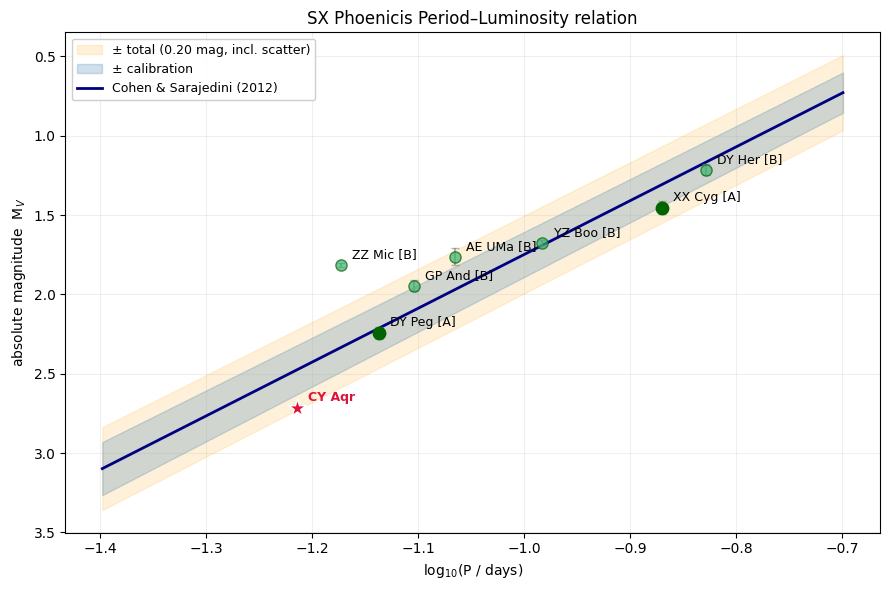

In [4]:
def plot_pl(table, highlight=None, savepath=None):
    """PL relation + reference stars. Optionally highlight one star by name."""
    logP = np.linspace(np.log10(0.04), np.log10(0.20), 200)
    M_line  = A_CS + B_CS * logP
    sig_cal = np.sqrt(A_ERR**2 + (logP * B_ERR)**2)
    sig_tot = np.sqrt(sig_cal**2 + SIGMA_INTRINSIC**2)

    fig, ax = plt.subplots(figsize=(9, 6))
    ax.fill_between(logP, M_line-sig_tot, M_line+sig_tot, color="orange", alpha=0.15,
                    label=f"± total ({SIGMA_INTRINSIC:.2f} mag, incl. scatter)")
    ax.fill_between(logP, M_line-sig_cal, M_line+sig_cal, color="steelblue",
                    alpha=0.25, label="± calibration")
    ax.plot(logP, M_line, "-", color="navy", lw=2, label="Cohen & Sarajedini (2012)")

    # render each star styled by quality grade (A solid, B lighter, C hollow)
    grade_style = {"A": dict(alpha=1.0, s=80,  facecolor="darkgreen"),
                   "B": dict(alpha=0.7, s=65,  facecolor="mediumseagreen"),
                   "C": dict(alpha=0.5, s=55,  facecolor="none")}
    for _, r in table.iterrows():
        lp = np.log10(r["period_days"])
        is_hl = (r["name"] == highlight)
        st = grade_style.get(r.get("quality", "A"), grade_style["A"])
        if is_hl:
            ax.scatter(lp, r["abs_mag_MV"], s=170, marker="*", color="crimson",
                       edgecolor="white", zorder=7)
        else:
            ax.scatter(lp, r["abs_mag_MV"], s=st["s"], marker="o",
                       facecolor=st["facecolor"], edgecolor="darkgreen",
                       alpha=st["alpha"], zorder=5)
        # error bar from the parallax-propagated M_V uncertainty, if present
        if "MV_err" in r and pd.notna(r.get("MV_err")):
            ax.errorbar(lp, r["abs_mag_MV"], yerr=r["MV_err"], fmt="none",
                        ecolor="crimson" if is_hl else "gray",
                        alpha=0.6, capsize=3, zorder=4)
        ax.annotate(f"{r['name']}" + ("" if is_hl else f" [{r.get('quality','?')}]"),
                    (lp, r["abs_mag_MV"]), textcoords="offset points",
                    xytext=(8, 5), fontsize=9,
                    color="crimson" if is_hl else "black",
                    weight="bold" if is_hl else "normal")

    ax.invert_yaxis()
    ax.set_xlabel("log$_{10}$(P / days)")
    ax.set_ylabel("absolute magnitude  M$_V$")
    ax.set_title("SX Phoenicis Period–Luminosity relation")
    ax.legend(loc="upper left", fontsize=9, framealpha=0.95)
    ax.grid(alpha=0.2)
    plt.tight_layout()
    if savepath:
        plt.savefig(savepath, dpi=200, bbox_inches="tight"); print(f"saved {savepath}")
    plt.show()


plot_pl(sxphe, highlight="CY Aqr")

===== Self-derived PL relation (all stars) =====
  fit sample     : 8 stars
  M_V = -1.402(±0.688) + -3.170(±0.645)·log P
  Cohen&Sarajedini: M_V = -1.640(±0.110) + -3.389(±0.090)·log P
  difference     : Δintercept = +0.238 (2.2σ_CS),  Δslope = +0.219 (2.4σ_CS)

  per-star residuals (obs − your fit):
    CY Aqr  [A]  +0.267 mag
    ZZ Mic  [B]  -0.501 mag
    DY Peg  [A]  +0.041 mag
    GP And  [B]  -0.154 mag
    AE UMa  [B]  -0.212 mag
    YZ Boo  [B]  -0.038 mag
    XX Cyg  [A]  +0.097 mag
    DY Her  [B]  -0.008 mag


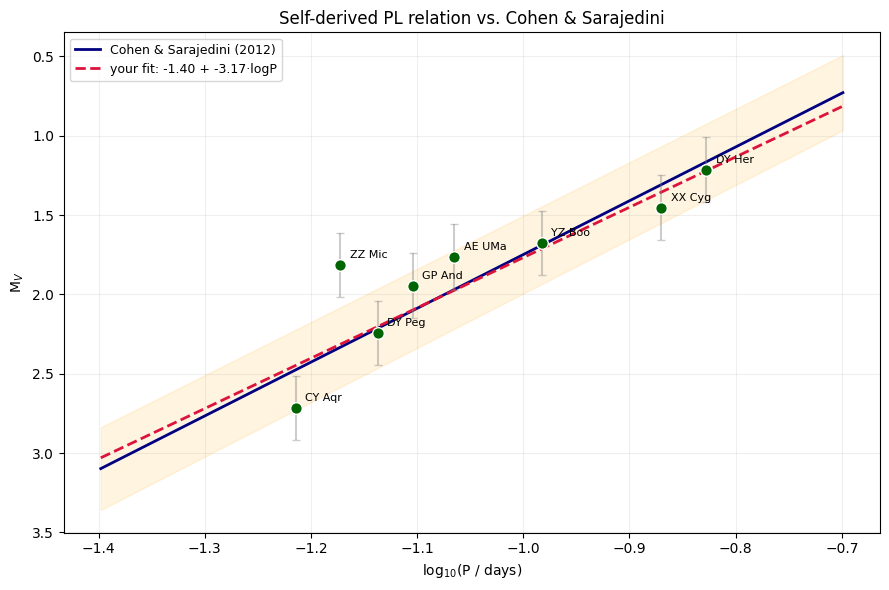

In [5]:
# Cell — Fit your own PL relation and compare to Cohen & Sarajedini
#   Weighted linear least squares: M_V = a + b*log10(P)
#   Weights = 1/sigma^2 where sigma = parallax M_V error (+) intrinsic scatter.
#   CY Aqr can be held OUT (independent test) or included.

def fit_pl_relation(table, hold_out="CY Aqr", downweight_B=False,
                    use_intrinsic=True):
    """Weighted least-squares fit of M_V = a + b*log10(P) to the table.
    hold_out: star name to exclude from the fit (tested separately), or None."""
    df = table.copy()
    df["logP"] = np.log10(df["period_days"])

    sig = df["MV_err"].fillna(0.05).values.astype(float)
    if use_intrinsic:
        sig = np.sqrt(sig**2 + SIGMA_INTRINSIC**2)
    if downweight_B:
        mult = df["quality"].map({"A": 1.0, "B": 1.5, "C": 2.5}).fillna(2.0).values
        sig = sig * mult

    # is_out is ALWAYS a numpy bool array (fixes the None-case bug)
    is_out = ((df["name"] == hold_out).values if hold_out
              else np.zeros(len(df), bool))
    fit = df[~is_out]
    w   = 1.0 / sig[~is_out]**2
    x, y = fit["logP"].values, fit["abs_mag_MV"].values

    S   = w.sum(); Sx = (w*x).sum(); Sy = (w*y).sum()
    Sxx = (w*x*x).sum(); Sxy = (w*x*y).sum()
    delta = S*Sxx - Sx*Sx
    b = (S*Sxy - Sx*Sy) / delta
    a = (Sxx*Sy - Sx*Sxy) / delta
    a_err = np.sqrt(Sxx/delta); b_err = np.sqrt(S/delta)

    df["M_pred"] = a + b*df["logP"]
    df["residual"] = df["abs_mag_MV"] - df["M_pred"]

    print(f"===== Self-derived PL relation "
          f"({'held out: '+hold_out if hold_out else 'all stars'}) =====")
    print(f"  fit sample     : {len(fit)} stars")
    print(f"  M_V = {a:.3f}(±{a_err:.3f}) + {b:.3f}(±{b_err:.3f})·log P")
    print(f"  Cohen&Sarajedini: M_V = {A_CS:.3f}(±{A_ERR:.3f}) + "
          f"{B_CS:.3f}(±{B_ERR:.3f})·log P")
    da = a - A_CS; db = b - B_CS
    print(f"  difference     : Δintercept = {da:+.3f} ({abs(da)/A_ERR:.1f}σ_CS),  "
          f"Δslope = {db:+.3f} ({abs(db)/B_ERR:.1f}σ_CS)")
    print(f"\n  per-star residuals (obs − your fit):")
    for _, r in df.sort_values("logP").iterrows():
        flag = "  <-- HELD OUT" if (hold_out and r["name"]==hold_out) else ""
        print(f"    {r['name']:7s} [{r['quality']}]  {r['residual']:+.3f} mag{flag}")

    return {"a": a, "b": b, "a_err": a_err, "b_err": b_err,
            "table": df, "hold_out": hold_out}

def plot_pl_with_fit(fitres, table):
    """Overlay the self-derived fit on the C&S line + stars."""
    a, b = fitres["a"], fitres["b"]; df = fitres["table"]
    logP = np.linspace(np.log10(0.04), np.log10(0.20), 200)

    fig, ax = plt.subplots(figsize=(9, 6))
    # C&S reference + band
    M_cs = A_CS + B_CS*logP
    sig_tot = np.sqrt(A_ERR**2 + (logP*B_ERR)**2 + SIGMA_INTRINSIC**2)
    ax.fill_between(logP, M_cs-sig_tot, M_cs+sig_tot, color="orange", alpha=0.12)
    ax.plot(logP, M_cs, "-", color="navy", lw=2, label="Cohen & Sarajedini (2012)")
    # your fit
    ax.plot(logP, a + b*logP, "--", color="crimson", lw=2,
            label=f"your fit: {a:.2f} + {b:.2f}·logP")
    # stars
    for _, r in df.iterrows():
        out = (fitres["hold_out"] and r["name"]==fitres["hold_out"])
        ax.scatter(r["logP"], r["abs_mag_MV"],
                   s=140 if out else 70, marker="*" if out else "o",
                   color="crimson" if out else "darkgreen",
                   edgecolor="white", zorder=6 if out else 5)
        ax.errorbar(r["logP"], r["abs_mag_MV"],
                    yerr=np.sqrt(r["MV_err"]**2 + SIGMA_INTRINSIC**2),
                    fmt="none", ecolor="gray", alpha=0.4, capsize=3)
        ax.annotate(r["name"], (r["logP"], r["abs_mag_MV"]),
                    textcoords="offset points", xytext=(7,5), fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel("log$_{10}$(P / days)"); ax.set_ylabel("M$_V$")
    ax.set_title("Self-derived PL relation vs. Cohen & Sarajedini")
    ax.legend(loc="upper left", fontsize=9); ax.grid(alpha=0.2)
    plt.tight_layout(); plt.show()


# --- run: hold CY Aqr out, fit the other 7, compare to C&S ---
fit = fit_pl_relation(sxphe, hold_out=None, downweight_B=True)
plot_pl_with_fit(fit, sxphe)

## 5 · Your observation → pipeline

Run your own AAVSO-format CSV through the full chain: recover the period (a
validation that needs 3+ cycles), fold to an intensity mean, and derive a
distance from the PL relation. Set `is_standard_V=False` for untransformed data
(e.g. OSC green) — the distance is still shown but flagged as uncalibrated.

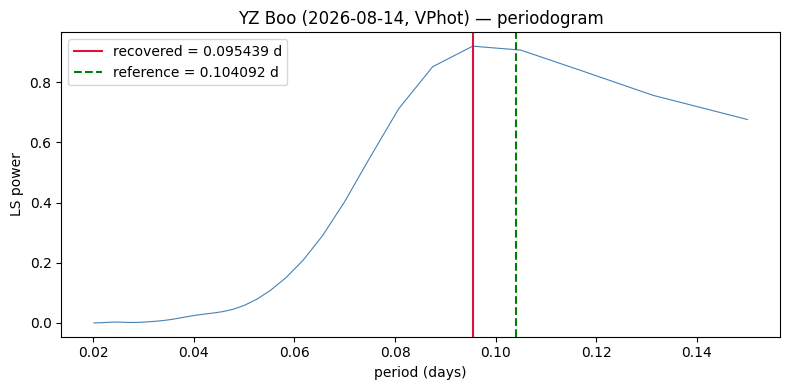

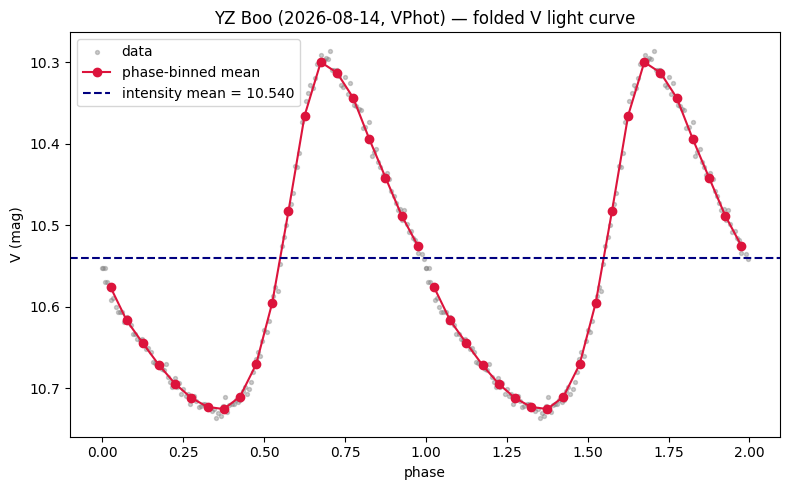


===== YZ Boo (2026-08-14, VPhot) (band V) =====
  points          : 150
  baseline        : 1.0 cycles
  period recovered: 137.433 min  (8.31% off)
  phase coverage  : 100%  (0 empty)
  intensity mean  : 10.540 V
  M_V (from P)    : 1.690 ± 0.245
  distance        : 562 ± 65 pc  (12%)   [UNCALIBRATED — not standard V]



In [6]:
def _parse_aavso_extended(path):
    """Shared header/row parser for an AAVSO Extended Format report. Returns
    (df, meta_kv) with every column as a string except MAG/DATE/KMAG, which are
    pre-coerced to numeric ('mag', 't', 'kmag'). Used by load_aavso_extended
    (variable magnitude) and load_check_star (comparison-star magnitude) so both
    stay in sync with the file format."""
    meta_kv, columns, rows = {}, None, []
    with open(path) as fh:
        for line in fh:
            line = line.rstrip("\n")
            if line.startswith("#"):
                body = line[1:]
                if "=" in body:
                    k, v = body.split("=", 1)
                    meta_kv[k.strip()] = v.strip()
                else:
                    columns = body.split(",")
            elif line.strip():
                rows.append(line)
    if columns is None:
        raise ValueError(f"{path}: no '#NAME,DATE,...' header line found")
    delim = meta_kv.get("DELIM", ",")
    split_rows = [r.split(delim, len(columns) - 1) for r in rows]
    df = pd.DataFrame(split_rows, columns=columns)
    df["mag"] = pd.to_numeric(df["MAG"], errors="coerce")
    df["t"] = pd.to_numeric(df["DATE"], errors="coerce")
    df["kmag"] = pd.to_numeric(df["KMAG"], errors="coerce")
    return df, meta_kv


def load_aavso_extended(path, band="V", transformed_only=False, densest_night=False):
    """Load a single-observer AAVSO 'Extended Format' report (e.g. a VPhot export).

    This is a DIFFERENT format from the multi-observer WebObs CSVs used for the
    reference sample (load_aavso): metadata lives in leading '#KEY=VALUE' lines,
    the column header is itself a '#'-prefixed line (NAME,DATE,MAG,MERR,FILT,TRANS,
    MTYPE,CNAME,CMAG,KNAME,KMAG,AMASS,GROUP,CHART,NOTES) rather than WebObs's
    JD/Magnitude/Band/Transfomed/..., dates are already whatever #DATE declares
    (JD here, not HJD), there's no per-row Validation Flag (a single VPhot run is
    pre-vetted), and the trailing NOTES field itself contains '|'-delimited
    key=value pairs -- it's split off whole rather than exploded into columns.
    Returns (times, mags, meta) with the same shape as load_aavso.
    """
    df, meta_kv = _parse_aavso_extended(path)
    date_kind = meta_kv.get("DATE", "JD")

    sel = df["FILT"] == band
    d = df[sel].copy()
    if transformed_only:
        d = d[d["TRANS"].str.upper() == "YES"]
    d = d.dropna(subset=["mag", "t"]).sort_values("t")
    meta = {"n_total": int(sel.sum()), "n_clean": len(d), "tcol": date_kind,
            "obscode": meta_kv.get("OBSCODE"), "software": meta_kv.get("SOFTWARE")}
    if densest_night:
        d["night"] = np.floor(d["t"] - 0.5).astype(int)
        best = d.groupby("night").size().sort_values(ascending=False).index[0]
        d = d[d["night"] == best]
        meta.update(night=int(best), n_night=len(d),
                    span_hours=(d["t"].max()-d["t"].min())*24)
    return d["t"].values, d["mag"].values, meta


def load_check_star(path, band="V"):
    """Check-star (KMAG) magnitude series from an AAVSO Extended Format report --
    the same ensemble comp-star measurement VPhot reports as a sanity check on
    each frame. A flat, unvarying scatter here means the comp stars held steady,
    so variation in the variable's own light curve is real, not a setup drift.
    Returns (times, mags, meta) with meta including the check star's KNAME.
    """
    df, meta_kv = _parse_aavso_extended(path)
    d = df[df["FILT"] == band].dropna(subset=["kmag", "t"]).sort_values("t")
    meta = {"n_clean": len(d),
            "kname": d["KNAME"].iloc[0] if len(d) else None}
    return d["t"].values, d["kmag"].values, meta


def run_pipeline(csv_path, star_name, period, band="V", densest_night=True,
                 A_V=A_V_DEFAULT, A_err=0.05, m_err=0.02, is_standard_V=True,
                 label=None, loader=load_aavso):
    """Full period -> fold -> mean -> distance on one dataset. Charts first,
    then a consolidated summary. Uses the star's OWN period for its M_V.
    loader: load_aavso for a WebObs multi-observer CSV (default), or
    load_aavso_extended for a single-observer AAVSO Extended Format report
    (e.g. exported from VPhot) -- pass whichever matches the file's format.
    """
    label = label or f"{star_name} ({csv_path})"
    times, mags, meta = loader(csv_path, band=band, densest_night=densest_night)

    period_rec, pdiag = find_period(times, mags)
    plot_periodogram(pdiag, known_period=period, title=f"{label} — periodogram")

    mean_mag, fdiag = fold_and_mean(times, mags, period)
    plot_folded(fdiag, title=f"{label} — folded {band} light curve", band=band)

    M_V, M_err = period_to_absmag(period)                # this star's own M_V
    d, d_err = distance_from_modulus(mean_mag, M_V, A_V=A_V,
                                     m_err=m_err, M_err=M_err, A_err=A_err)
    pct_off  = 100*abs(period_rec - period)/period
    n_cycles = (times.max()-times.min())/period
    tag = "" if is_standard_V else "   [UNCALIBRATED — not standard V]"

    print("\n" + "\n".join([
        f"===== {label} (band {band}) =====",
        f"  points          : {meta['n_clean']}",
        f"  baseline        : {n_cycles:.1f} cycles",
        f"  period recovered: {period_rec*1440:.3f} min  ({pct_off:.2f}% off)",
        f"  phase coverage  : {100*fdiag['coverage']:.0f}%  ({fdiag['n_empty']} empty)",
        f"  intensity mean  : {mean_mag:.3f} {band}",
        f"  M_V (from P)    : {M_V:.3f} ± {M_err:.3f}",
        f"  distance        : {d:.0f} ± {d_err:.0f} pc  ({100*d_err/d:.0f}%){tag}",
    ]) + "\n")

    return {"label": label, "star": star_name, "band": band, "meta": meta,
            "period_recovered": period_rec, "pct_off": pct_off,
            "mean_mag": mean_mag, "M_V": M_V, "M_err": M_err,
            "distance_pc": d, "distance_err_pc": d_err,
            "is_standard_V": is_standard_V, "fdiag": fdiag}


# Your data: YZ Boo, shot 2026-08-14, reduced in VPhot (single-observer Extended
# Format report -> use load_aavso_extended). Whole file is one night, so
# densest_night=False just uses all of it. Period from the reference sample.
# TRANS=NO on every row of this file (no color-term transformation applied yet --
# that needs a calibrated standard-field run to derive Tv), so this is flagged
# is_standard_V=False: instrumental-ish V, not a true standard-system magnitude.
res = run_pipeline("sxphe_data/AAVSOReport_YZ-Boo_V_20260814.txt", "YZ Boo",
                   0.104091579, band="V", densest_night=False,
                   loader=load_aavso_extended, is_standard_V=False,
                   label="YZ Boo (2026-08-14, VPhot)")

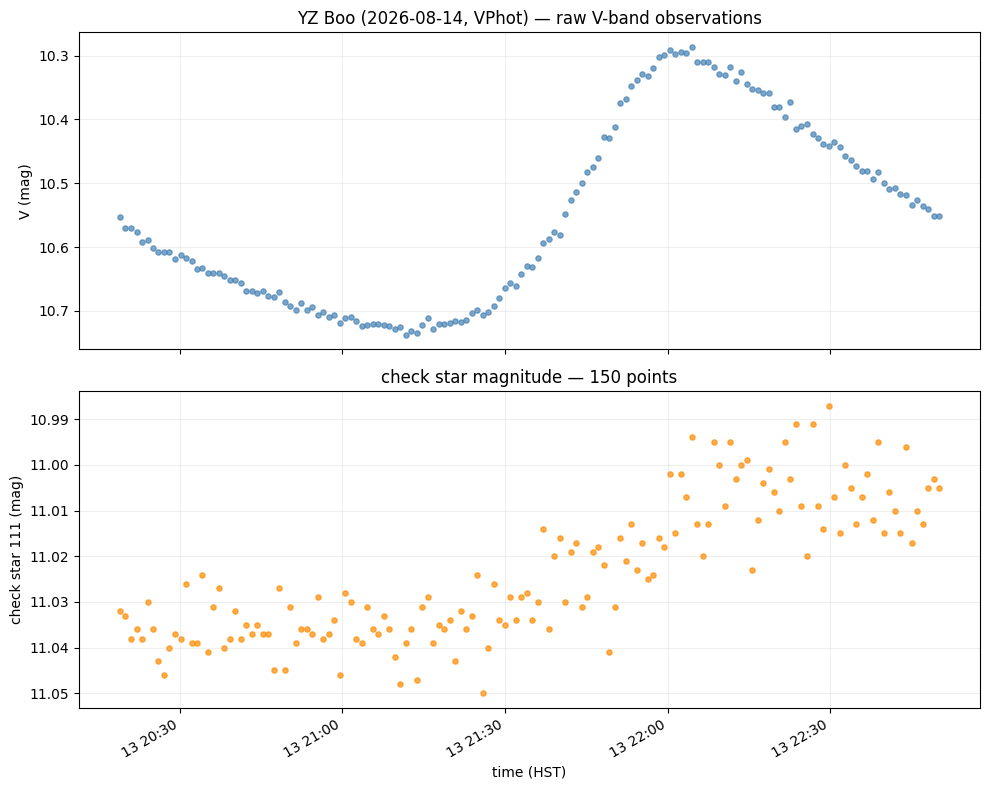

In [7]:
# --- raw light curve: V mag vs. time (HST), one point per observation ------
def plot_raw_lightcurve(csv_path, band="V", loader=load_aavso_extended,
                        tz_offset_hours=-10, title=None, show_check_star=True):
    """Scatter every individual data point: magnitude vs. time-of-night in HST.
    tz_offset_hours=-10 is Hawaii Standard Time (no DST, fixed UTC-10).
    show_check_star=True adds a second panel with the check star's KMAG over the
    same night (only for the Extended Format loader, which is the only one that
    carries KMAG) -- a flat scatter there confirms the comp/check ensemble was
    stable, so the variable's own scatter/trend above is real, not equipment
    drift."""
    times, mags, meta = loader(csv_path, band=band, densest_night=False)
    t_hst = Time(times, format="jd") + tz_offset_hours * u.hour
    hst_dt = np.array(t_hst.to_datetime())
    order = np.argsort(hst_dt)
    hst_dt = hst_dt[order]
    mags_sorted = np.asarray(mags)[order]

    has_check = show_check_star and loader is load_aavso_extended
    if has_check:
        ktimes, kmags, kmeta = load_check_star(csv_path, band=band)
        kt_hst = np.array((Time(ktimes, format="jd") + tz_offset_hours * u.hour).to_datetime())
        korder = np.argsort(kt_hst)
        kt_hst = kt_hst[korder]
        kmags_sorted = np.asarray(kmags)[korder]

    fig, axes = plt.subplots(2 if has_check else 1, 1,
                             figsize=(10, 8 if has_check else 5), sharex=True)
    ax0 = axes[0] if has_check else axes
    ax0.scatter(hst_dt, mags_sorted, s=14, alpha=0.7, color="steelblue")
    ax0.invert_yaxis()
    ax0.set_ylabel(f"{band} (mag)")
    ax0.set_title(title or f"raw {band}-band light curve — {meta['n_clean']} points (HST)")
    ax0.grid(alpha=0.2)

    if has_check:
        ax1 = axes[1]
        ax1.scatter(kt_hst, kmags_sorted, s=14, alpha=0.7, color="darkorange")
        ax1.invert_yaxis()
        ax1.set_xlabel("time (HST)")
        ax1.set_ylabel(f"check star {kmeta['kname']} (mag)")
        ax1.set_title(f"check star magnitude — {kmeta['n_clean']} points")
        ax1.grid(alpha=0.2)
    else:
        ax0.set_xlabel("time (HST)")

    fig.autofmt_xdate()
    plt.tight_layout(); plt.show()


plot_raw_lightcurve("sxphe_data/AAVSOReport_YZ-Boo_V_20260814.txt", band="V",
                    title="YZ Boo (2026-08-14, VPhot) — raw V-band observations")

## 6 · Compare your result against the reference table

Verdict of a pipeline result against a star's cached Gaia distance and true M_V.
Works for any star that has both a pipeline run and a table row.

In [8]:
PC_TO_LY = 3.2616  # 1 parsec in light years

def compare_to_table(res, table, A_V=A_V_DEFAULT):
    """Ground truth vs. your measurement, one row per quantity, plus the delta.

    Ground truth: literature period, archival AAVSO mean mag, the table's
    Gaia-distance-derived M_V, and the Gaia distance itself (pc and ly).
    Yours: period recovered from your data, your intensity mean, YOUR apparent
    mag converted to M_V via the SAME Gaia distance (so this row isolates your
    photometric error, not the PL relation), and the distance the pipeline
    derives from the PL relation (period -> M_V) + your apparent mag.
    """
    row = table[table["name"] == res["star"]]
    if len(row) == 0:
        print(f"{res['star']} not in table — build it first."); return None
    row = row.iloc[0]

    M_V_yours = absmag_from_distance(res["mean_mag"], row["gaia_dist_pc"], A_V=A_V)

    rows = [
        ("period (days)",        row["period_days"],  res["period_recovered"]),
        (f"apparent mean {res['band']} (mag)", row["app_mean_V"], res["mean_mag"]),
        ("absolute M_V (mag)",   row["abs_mag_MV"],    M_V_yours),
        ("distance (pc)",        row["gaia_dist_pc"],  res["distance_pc"]),
        ("distance (ly)",        row["gaia_dist_pc"] * PC_TO_LY,
                                  res["distance_pc"] * PC_TO_LY),
    ]
    out = pd.DataFrame(rows, columns=["quantity", "ground truth", "your data"])
    out["delta"] = out["your data"] - out["ground truth"]

    print(f"===== {res['star']}: ground truth vs. your measurement =====")
    print(out.to_string(index=False, float_format=lambda x: f"{x:.4f}"))
    return out


# YZ Boo is already in the reference table (from its own AAVSO archival CSV), so
# this checks your one-night VPhot measurement against that Gaia-anchored row.
compare_to_table(res, sxphe)

===== YZ Boo: ground truth vs. your measurement =====
             quantity  ground truth  your data    delta
        period (days)        0.1041     0.0954  -0.0087
apparent mean V (mag)       10.5932    10.5400  -0.0532
   absolute M_V (mag)        1.6746     1.6214  -0.0532
        distance (pc)      580.3998   562.3502 -18.0496
        distance (ly)     1893.0319  1834.1615 -58.8705


,quantity,ground truth,your data,delta
0,period (days),0.104092,0.095439,-0.008652
1,apparent mean V (mag),10.593214,10.540013,-0.053201
2,absolute M_V (mag),1.674578,1.621377,-0.053201
3,distance (pc),580.399780,562.350213,-18.049567
4,distance (ly),1893.031923,1834.161456,-58.870468
